## Import libraries & set random seed

In [ ]:
import numpy as np
import pandas as pd
import os
import random
import warnings
import cv2
import torch
import torch.nn as nn
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import alexnet, AlexNet_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm

warnings.filterwarnings('ignore')

manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)

Random Seed:  999
Image 1: ISIC_9730802.jpg - Size: (139, 139)
Image 2: ISIC_2834883.jpg - Size: (125, 125)
Image 3: ISIC_5115027.jpg - Size: (123, 123)
Image 4: ISIC_3264822.jpg - Size: (115, 115)
Image 5: ISIC_1950204.jpg - Size: (147, 147)
Image 6: ISIC_8411738.jpg - Size: (145, 145)
Image 7: ISIC_3744117.jpg - Size: (133, 133)
Image 8: ISIC_0989720.jpg - Size: (131, 131)
Image 9: ISIC_3926794.jpg - Size: (139, 139)
Image 10: ISIC_2892810.jpg - Size: (107, 107)


## Load & Filter Data

In [ ]:
meta_dir = "/kaggle/input/competitions/isic-2024-challenge/"
df = pd.read_csv(meta_dir + "train-metadata.csv")
df.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0,IP_4111386,65.0,male,anterior torso,3.22,TBP tile: close-up,3D: XP,14.242329,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0,IP_8313778,55.0,male,anterior torso,2.73,TBP tile: close-up,3D: white,24.725520,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


## Visualize with the malignant skin cancer cells

In [ ]:
df_filtered = df[df["target"] == 1].reset_index(drop=True)
df_filtered.head()

,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0082829,1,IP_3249371,80.0,female,anterior torso,9.27,TBP tile: close-up,3D: XP,18.093368,...,IL_7881385,Malignant::Malignant epidermal proliferations:...,Malignant,Malignant epidermal proliferations,Squamous cell carcinoma in situ,NaN,NaN,NaN,NaN,72.211683
1,ISIC_0096034,1,IP_6723298,75.0,male,head/neck,3.88,TBP tile: close-up,3D: white,26.187010,...,IL_5240575,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular",NaN,NaN,NaN,94.559590
2,ISIC_0104229,1,IP_9057861,80.0,male,anterior torso,6.55,TBP tile: close-up,3D: white,33.480140,...,IL_1702337,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Nodular",NaN,NaN,NaN,66.196170
3,ISIC_0119495,1,IP_6856511,60.0,male,upper extremity,5.27,TBP tile: close-up,3D: white,25.872050,...,IL_3266850,Malignant::Malignant epidermal proliferations:...,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,NaN,NaN,NaN,99.991270
4,ISIC_0157834,1,IP_3927284,55.0,male,posterior torso,5.29,TBP tile: close-up,3D: white,30.966662,...,IL_2429082,Malignant::Malignant adnexal epithelial prolif...,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,"Basal cell carcinoma, Superficial",NaN,NaN,NaN,99.960846


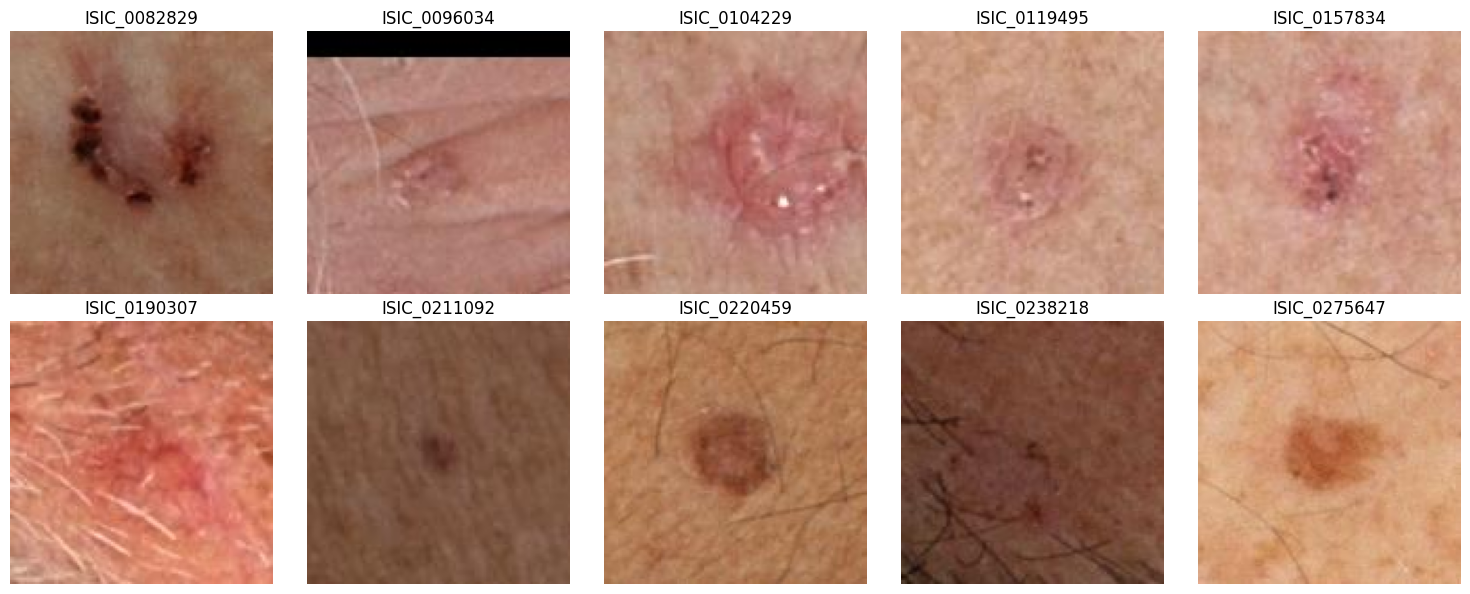

In [ ]:
isic_ids = df_filtered['isic_id'].head(10)

plt.figure(figsize=(15, 6))
for i, isic_id in enumerate(isic_ids):
    image_path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = Image.open(image_path).convert("RGB")
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Apply yuv clahe preprocessing technique

In [ ]:
save_dir = '/kaggle/working/clahe_images'
os.makedirs(save_dir, exist_ok=True)

isic_ids = df_filtered['isic_id'].head(10)
plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    y_channel = yuv[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    yuv[:, :, 0] = clahe.apply(y_channel)
    clahe_img = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    save_path = os.path.join(save_dir, f"{isic_id}_clahe.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(clahe_img, cv2.COLOR_RGB2BGR))

    plt.subplot(2, 5, i + 1)
    plt.imshow(clahe_img)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Apply LAB clahe preprocessing technique

In [ ]:
save_dir_lab = '/kaggle/working/clahe_images_lab_preview'
os.makedirs(save_dir_lab, exist_ok=True)

isic_ids = df_filtered['isic_id'].head(10)
plt.figure(figsize=(15, 6))

for i, isic_id in enumerate(isic_ids):
    path = os.path.join(image_dir, f"{isic_id}.jpg")
    img = cv2.imread(path)
    if img is None:
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_CUBIC)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_Lab2RGB)

    save_path = os.path.join(save_dir_lab, f"{isic_id}_clahe.jpg")
    cv2.imwrite(save_path, cv2.cvtColor(img_clahe, cv2.COLOR_RGB2BGR))

    plt.subplot(2, 5, i + 1)
    plt.imshow(img_clahe)
    plt.title(isic_id)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Apply Hair Removal preprocessing technique function (DullRazor)

In [ ]:
def remove_hairs_dullrazor(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    hair_mask = cv2.dilate(hair_mask, np.ones((3, 3), np.uint8), iterations=1)
    inpainted = cv2.inpaint(img, hair_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return inpainted

## Apply Hair Removal preprocessing technique function (Morphological closing)

In [ ]:
def remove_hairs_v2(img):
    img = img.copy()
    kernel = np.ones((15,15), np.uint8)

    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=2)
    blurred = cv2.blur(closed, (15,15))

    gray = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img

    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest_contour], -1, 255, -1)

    mean_color = cv2.mean(img, mask=mask)[:3]
    mean_color = tuple(map(int, mean_color))

    result = img.copy()
    h, w = img.shape[:2]
    for y in range(h):
        for x in range(w):
            if mask[y, x]:
                b, g, r = result[y, x]
                if r < mean_color[2]*0.8 or g < mean_color[1]*0.8 or b < mean_color[0]*0.8:
                    result[y, x] = mean_color

    return result

## Experiment with different Preprocessing techniques 

In [ ]:
save_dir = '/kaggle/working/without_any'
os.makedirs(save_dir, exist_ok=True)

malignant_df = df[df["target"] == 1]
benign_df = df[df["target"] == 0].sample(n=10000, random_state=42)
df_filtered = pd.concat([malignant_df, benign_df]).reset_index(drop=True)

new_records = []

def augment_image(img):
    aug_imgs = []
    for angle in [90, 180, 270]:
        rotated = cv2.rotate(img, {
            90: cv2.ROTATE_90_CLOCKWISE,
            180: cv2.ROTATE_180,
            270: cv2.ROTATE_90_COUNTERCLOCKWISE
        }[angle])
        aug_imgs.append(rotated)
        aug_imgs.append(cv2.flip(rotated, 1))
    return aug_imgs

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered)):
    isic_id = row["isic_id"]
    label = row["target"]
    path = os.path.join(image_dir, f"{isic_id}.jpg")

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = remove_hairs_dullrazor(img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    out_path = os.path.join(save_dir, f"{isic_id}.jpg")
    cv2.imwrite(out_path, img)
    new_records.append({'isic_id': isic_id, 'target': label})
    
df_filtered = pd.DataFrame(new_records).reset_index(drop=True)

## Define Dataset Class

In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        isic_id = self.df.iloc[idx]["isic_id"]
        label = self.df.iloc[idx]["target"]
        img_path = os.path.join(self.img_dir, f"{isic_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_df, val_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered["target"], random_state=42)

train_dataset = SkinLesionDataset(train_df, save_dir, transform)
val_dataset = SkinLesionDataset(val_df, save_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

## AlexNet Binary Classifier model

In [ ]:
class AlexNetBinaryClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        try:
            weights = AlexNet_Weights.IMAGENET1K_V1 if pretrained else None
            self.backbone = alexnet(weights=weights)
            print(f"AlexNet backbone loaded (pretrained={pretrained})")
        except Exception as e:
            print(f"Could not load pretrained weights: {e}")
            self.backbone = alexnet(weights=None)

        in_feats = self.backbone.classifier[6].in_features
        self.backbone.classifier[6] = nn.Sequential(
            nn.Linear(in_feats, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        return self.backbone(x)

## Before preprocessing and After preprocessing Skin cancer cells visualization

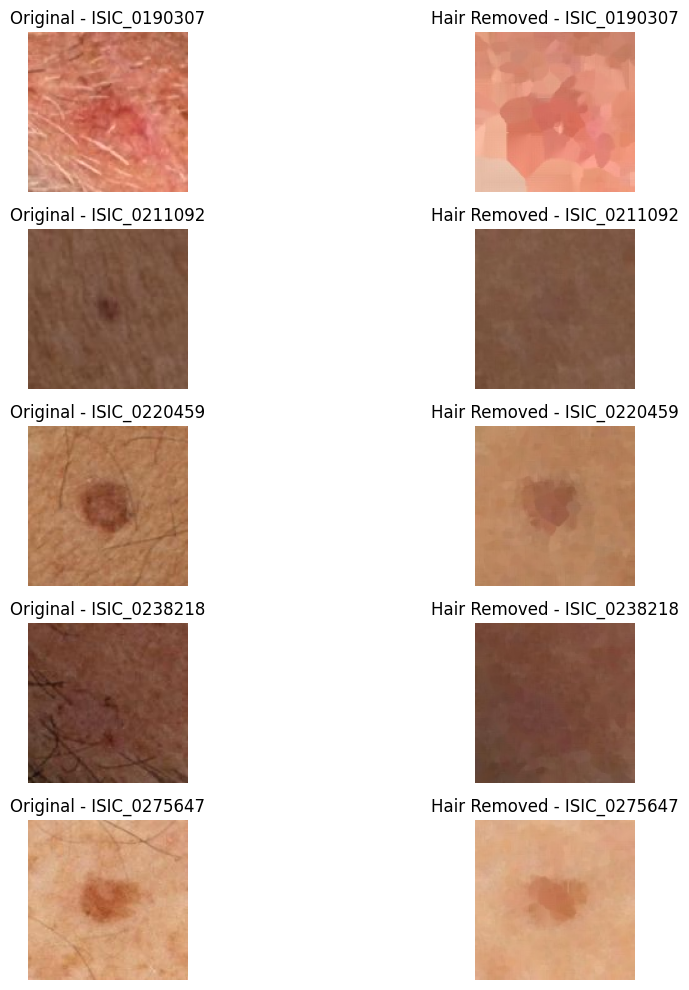

In [ ]:
def show_before_after(isic_ids, original_dir, processed_dir):
    plt.figure(figsize=(12, 10))
    for i, isic_id in enumerate(isic_ids):
        orig_path = os.path.join(original_dir, f"{isic_id}.jpg")
        orig_img = cv2.imread(orig_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

        proc_path = os.path.join(processed_dir, f"{isic_id}.jpg")
        proc_img = cv2.imread(proc_path)
        proc_img = cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(isic_ids), 2, 2 * i + 1)
        plt.imshow(orig_img)
        plt.title(f"Original - {isic_id}")
        plt.axis("off")

        plt.subplot(len(isic_ids), 2, 2 * i + 2)
        plt.imshow(proc_img)
        plt.title(f"Processed - {isic_id}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

sample_ids = df_filtered[df_filtered["isic_id"].str.contains("aug") == False]["isic_id"].iloc[5:10].tolist()
original_dir = '/kaggle/input/competitions/isic-2024-challenge/train-image/image'
processed_dir = '/kaggle/working/without_any'

show_before_after(sample_ids, original_dir, processed_dir)

## Model, Optimizer & Scheduler Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AlexNetBinaryClassifier(pretrained=True).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.8)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 187MB/s]  


✅ AlexNet backbone loaded (pretrained=True)


## Full training loop - run epochs using DullRazor preprocessing

In [ ]:
for epoch in range(10):
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(logits).detach().cpu().numpy() > 0.5
        train_preds.extend(preds.flatten())
        train_labels.extend(labels.cpu().numpy())

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device).float().unsqueeze(1)
            logits = model(imgs)
            loss = criterion(logits, labels)
            val_loss += loss.item() * imgs.size(0)
            preds = torch.sigmoid(logits).cpu().numpy() > 0.5
            val_preds.extend(preds.flatten())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader.dataset)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"Epoch {epoch+1}: "
          f"Train Loss = {avg_train_loss:.4f}, Train Acc = {train_acc:.4f}, "
          f"Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")

Epoch 1: Train Loss = 0.3542, Train Acc = 0.8497, Val Loss = 0.3017, Val Acc = 0.8875
Epoch 2: Train Loss = 0.3002, Train Acc = 0.8794, Val Loss = 0.2564, Val Acc = 0.8957
Epoch 3: Train Loss = 0.2713, Train Acc = 0.8844, Val Loss = 0.2849, Val Acc = 0.8816
Epoch 4: Train Loss = 0.2433, Train Acc = 0.8960, Val Loss = 0.2504, Val Acc = 0.8922
Epoch 5: Train Loss = 0.2232, Train Acc = 0.9057, Val Loss = 0.2667, Val Acc = 0.8993
Epoch 6: Train Loss = 0.1979, Train Acc = 0.9149, Val Loss = 0.2412, Val Acc = 0.9028
Epoch 7: Train Loss = 0.1897, Train Acc = 0.9221, Val Loss = 0.2220, Val Acc = 0.9079
Epoch 8: Train Loss = 0.1588, Train Acc = 0.9344, Val Loss = 0.2348, Val Acc = 0.9079
Epoch 9: Train Loss = 0.1613, Train Acc = 0.9335, Val Loss = 0.2447, Val Acc = 0.9036
Epoch 10: Train Loss = 0.1269, Train Acc = 0.9496, Val Loss = 0.2665, Val Acc = 0.9118


## Train using only Clahe preprocessing technique

Epoch 1: Train Loss = 0.3313, Train Acc = 0.8609, Val Loss = 0.2641, Val Acc = 0.8949

Epoch 2: Train Loss = 0.2469, Train Acc = 0.8963, Val Loss = 0.2104, Val Acc = 0.9087

Epoch 3: Train Loss = 0.2061, Train Acc = 0.9130, Val Loss = 0.2399, Val Acc = 0.9118

Epoch 4: Train Loss = 0.1686, Train Acc = 0.9276, Val Loss = 0.2129, Val Acc = 0.9142

Epoch 5: Train Loss = 0.1383, Train Acc = 0.9408, Val Loss = 0.1870, Val Acc = 0.9290

Epoch 6: Train Loss = 0.1287, Train Acc = 0.9494, Val Loss = 0.1718, Val Acc = 0.9349

Epoch 7: Train Loss = 0.1034, Train Acc = 0.9598, Val Loss = 0.2164, Val Acc = 0.9236

Epoch 8: Train Loss = 0.0697, Train Acc = 0.9713, Val Loss = 0.2401, Val Acc = 0.9349

Epoch 9: Train Loss = 0.0682, Train Acc = 0.9736, Val Loss = 0.2257, Val Acc = 0.9298

Epoch 10: Train Loss = 0.0583, Train Acc = 0.9775, Val Loss = 0.3523, Val Acc = 0.9271

## Train using LAB-CLAHE + Hair removal preprocessing Techniques

Epoch 1: Train Loss = 0.2789, Train Acc = 0.8853, Val Loss = 0.2576, Val Acc = 0.8989

Epoch 2: Train Loss = 0.2726, Train Acc = 0.8863, Val Loss = 0.2567, Val Acc = 0.8957

Epoch 3: Train Loss = 0.2563, Train Acc = 0.8938, Val Loss = 0.2741, Val Acc = 0.8961

Epoch 4: Train Loss = 0.2565, Train Acc = 0.8963, Val Loss = 0.2400, Val Acc = 0.9036

Epoch 5: Train Loss = 0.2497, Train Acc = 0.8958, Val Loss = 0.2718, Val Acc = 0.8922

Epoch 6: Train Loss = 0.2410, Train Acc = 0.9025, Val Loss = 0.2419, Val Acc = 0.8930

Epoch 7: Train Loss = 0.2357, Train Acc = 0.9027, Val Loss = 0.2345, Val Acc = 0.9032

Epoch 8: Train Loss = 0.2318, Train Acc = 0.9043, Val Loss = 0.2346, Val Acc = 0.9004

Epoch 9: Train Loss = 0.2331, Train Acc = 0.9032, Val Loss = 0.2611, Val Acc = 0.8996

Epoch 10: Train Loss = 0.2143, Train Acc = 0.9065, Val Loss = 0.2184, Val Acc = 0.9055

## Train using only hair removal preprocessing technique 

Epoch 1: Train Loss = 0.5983, Train Acc = 0.7805, Val Loss = 0.5219, Val Acc = 0.7844

Epoch 2: Train Loss = 0.5241, Train Acc = 0.7842, Val Loss = 0.5214, Val Acc = 0.7844

Epoch 3: Train Loss = 0.5241, Train Acc = 0.7842, Val Loss = 0.5214, Val Acc = 0.7844

Epoch 4: Train Loss = 0.5239, Train Acc = 0.7842, Val Loss = 0.5214, Val Acc = 0.7844

Epoch 5: Train Loss = 0.5236, Train Acc = 0.7842, Val Loss = 0.5217, Val Acc = 0.7844

Epoch 6: Train Loss = 0.5249, Train Acc = 0.7842, Val Loss = 0.5216, Val Acc = 0.7844

Epoch 7: Train Loss = 0.5242, Train Acc = 0.7842, Val Loss = 0.5216, Val Acc = 0.7844

Epoch 8: Train Loss = 0.5242, Train Acc = 0.7842, Val Loss = 0.5213, Val Acc = 0.7844

Epoch 9: Train Loss = 0.5257, Train Acc = 0.7842, Val Loss = 0.5209, Val Acc = 0.7844

Epoch 10: Train Loss = 0.5240, Train Acc = 0.7842, Val Loss = 0.5219, Val Acc = 0.7844